# Computer Vision Lab 5 - Image Segmentation

## Name - Manan Chahal
## Roll No - 23102C0044

In [1]:
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from google.colab.patches import cv2_imshow

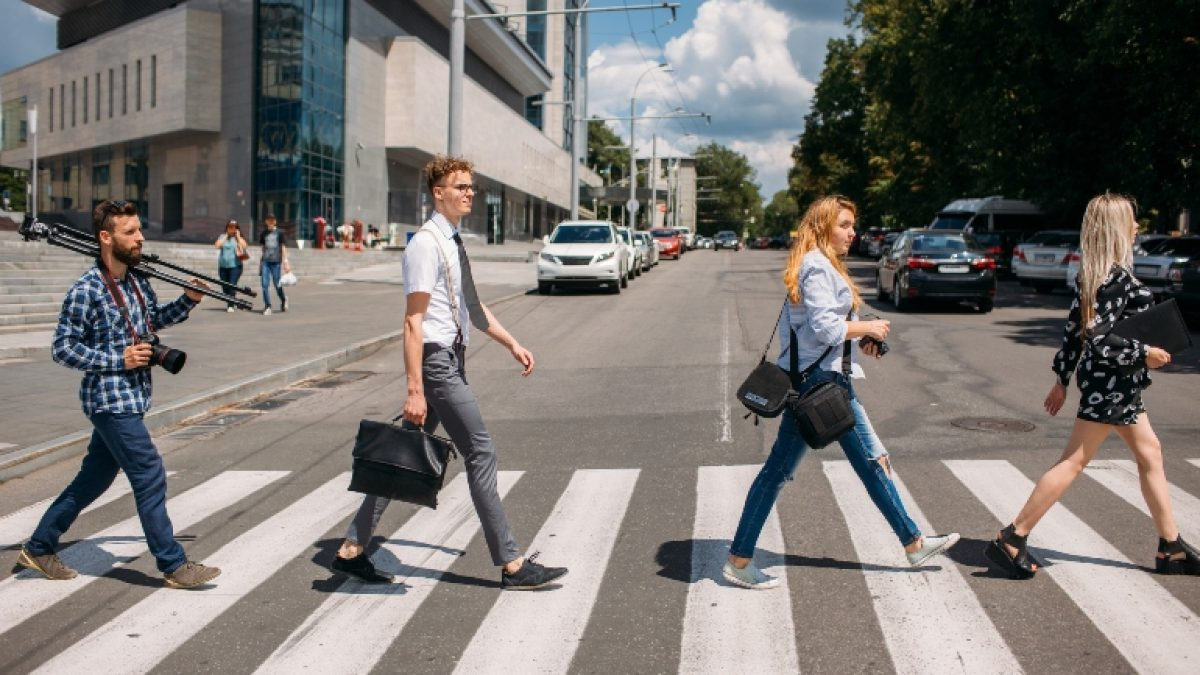

In [2]:
img = cv2.imread('./crosswalk.jpg')
#img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

cv2_imshow(img)


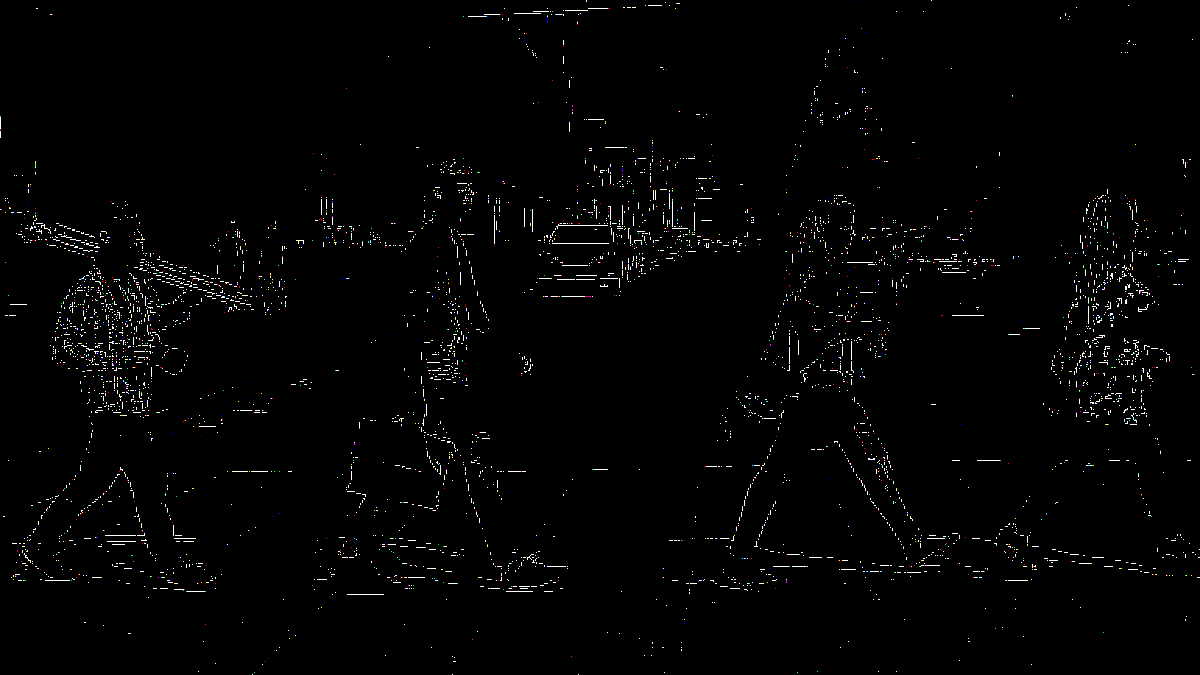

In [3]:
kernal = [[-1,-1,-1],
          [-1,8,-1],
          [-1,-1,-1]]

point_img = cv2.filter2D(img, -1, np.array(kernal))
point_img = cv2.threshold(point_img, 170, 255, cv2.THRESH_BINARY)[1]
cv2_imshow(point_img)


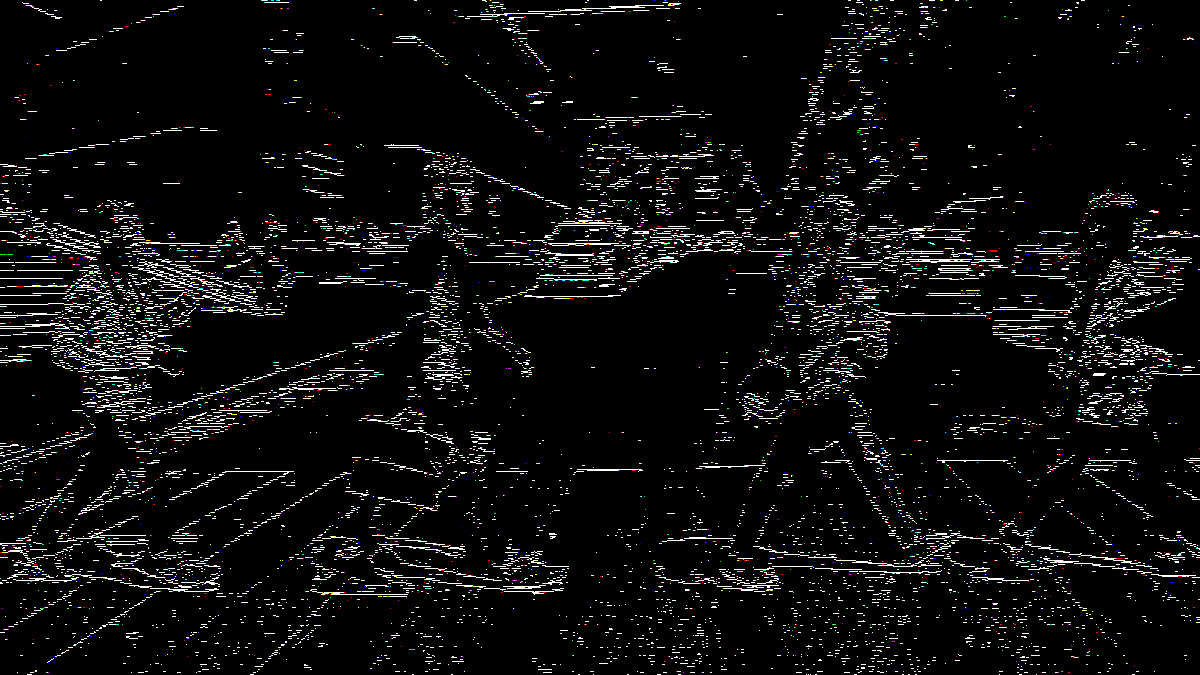

In [4]:

horizontal_kernal = [
    [-1, -1, -1],
    [2, 2, 2],
    [-1, -1, -1]
]

horizontal_img = cv2.filter2D(img, -1, np.array(horizontal_kernal))
horizontal_img = cv2.threshold(horizontal_img, 40, 255, cv2.THRESH_BINARY)[1]
cv2_imshow(horizontal_img)



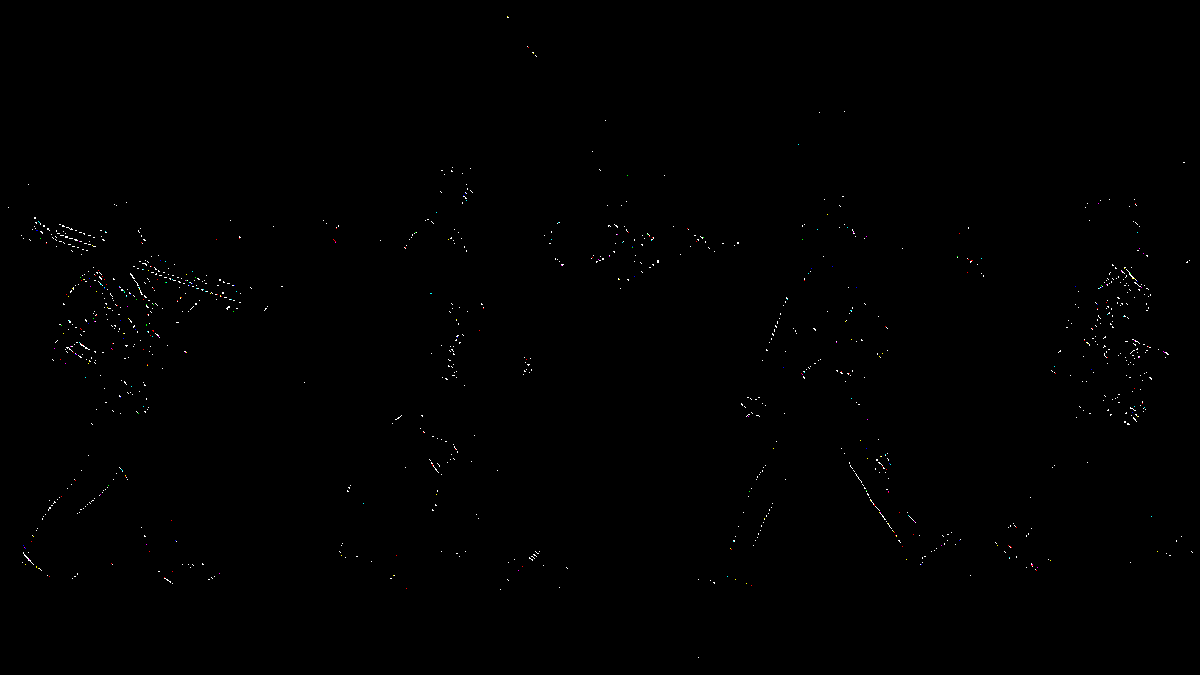

In [5]:
pos_45_kernal = [
    [2,-1,-1],
    [-1,2,-1],
    [-1,-1,2],
]
pos_45_img = cv2.filter2D(img, -1, np.array(pos_45_kernal))
pos_45_img = cv2.threshold(pos_45_img, 127, 255, cv2.THRESH_BINARY)[1]
cv2_imshow(pos_45_img)

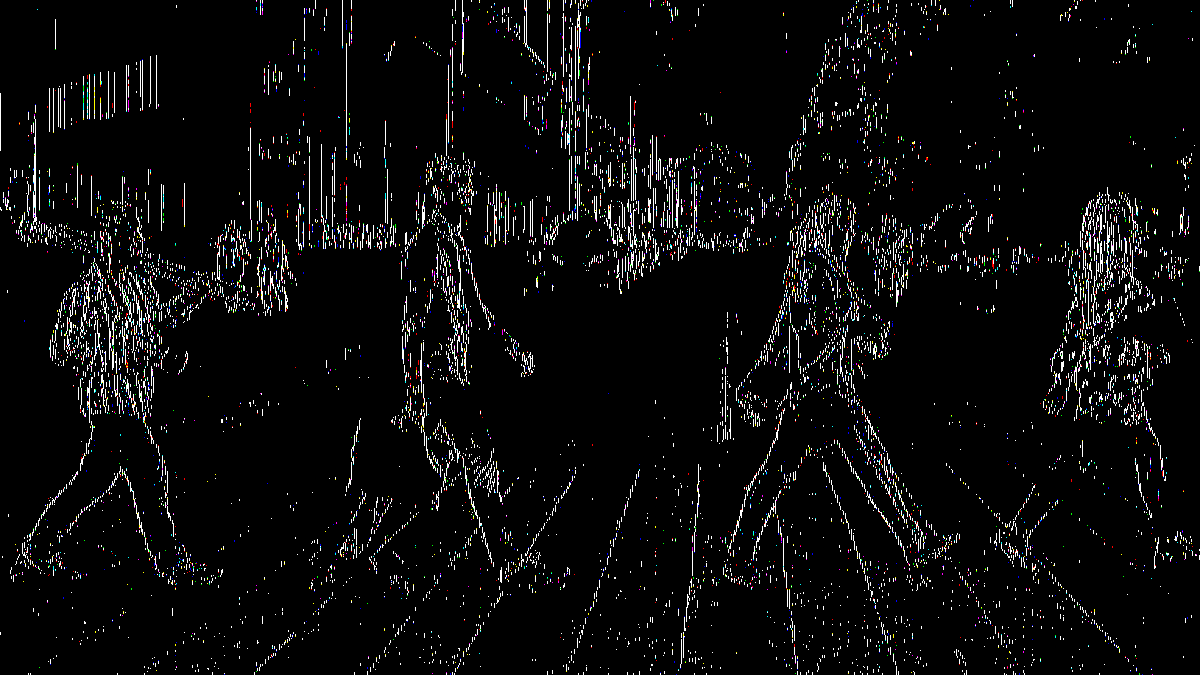

In [6]:
vertical_kernal = [
        [-1,2,-1],
        [-1,2,-1],
        [-1,2,-1],
]
vertical_img = cv2.filter2D(img, -1, np.array(vertical_kernal))
vertical_img = cv2.threshold(vertical_img, 40, 255, cv2.THRESH_BINARY)[1]
cv2_imshow(vertical_img)

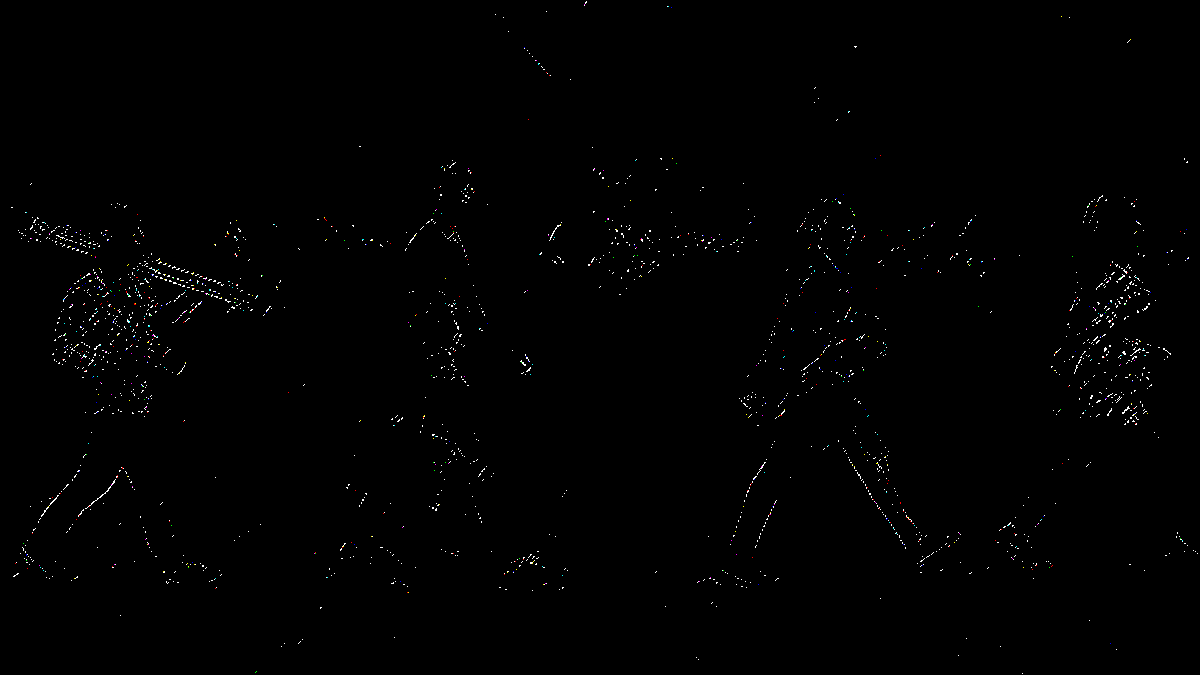

In [7]:
neg_45_kernal = [
    [-1,-1,2],
    [-1,2,-1],
    [2,-1,-1],
]
neg_45_img = cv2.filter2D(img, -1, np.array(neg_45_kernal))
neg_45_img = cv2.threshold(neg_45_img, 100, 255, cv2.THRESH_BINARY)[1]
cv2_imshow(neg_45_img)

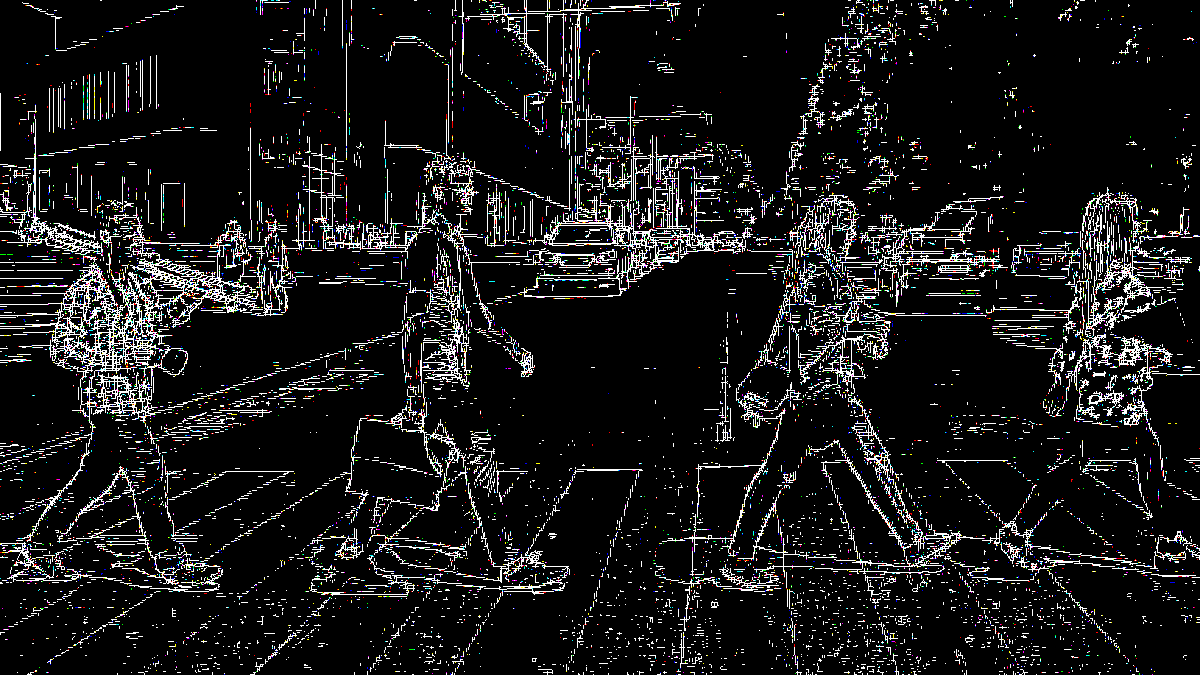

In [8]:

sum_edge_img = cv2.add(horizontal_img, vertical_img)
sum_edge_img = cv2.add(sum_edge_img, pos_45_img)
sum_edge_img = cv2.add(sum_edge_img, neg_45_img)

cv2_imshow(sum_edge_img)


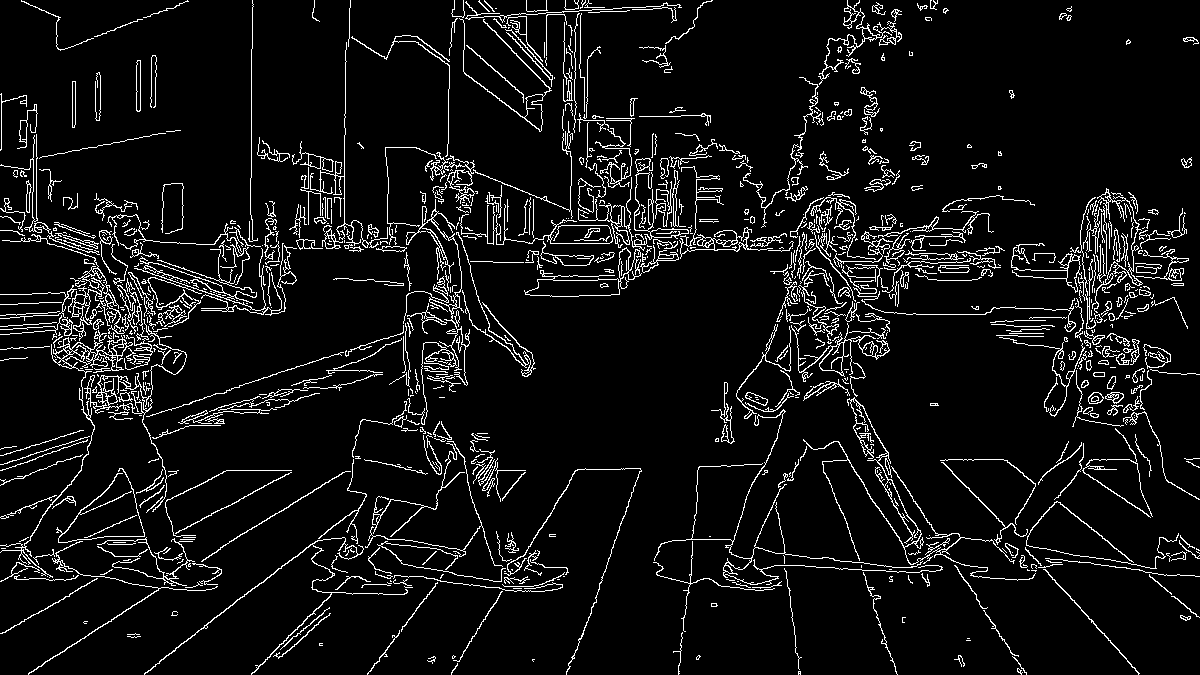

In [9]:
edge_img = cv2.Canny(img, 87,255)
cv2_imshow(edge_img)


# Thresholding

Otsu Global Thresholding Result:


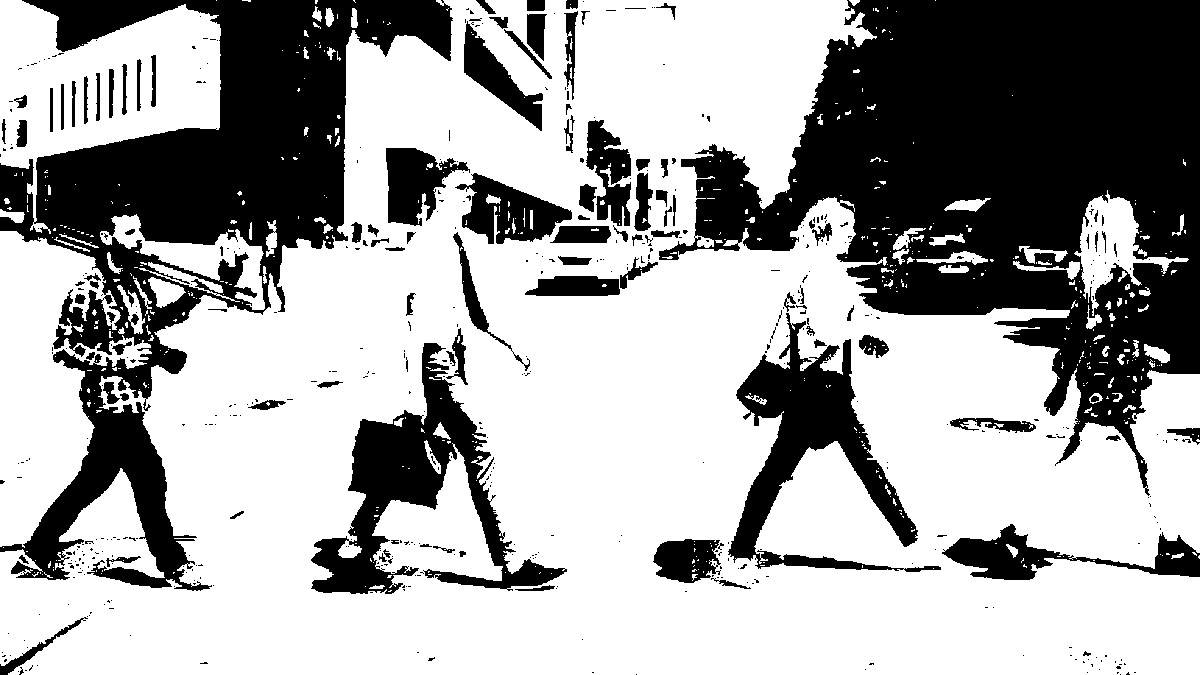

Adaptive Gaussian Thresholding Result:


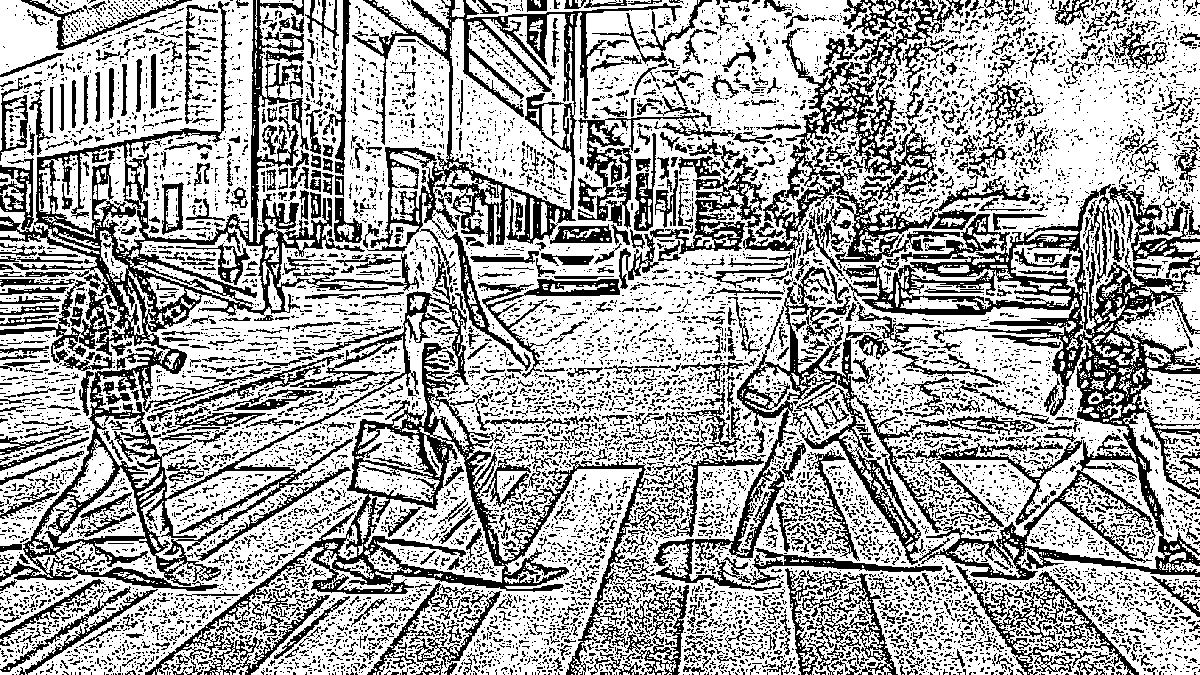

In [10]:
# Convert image to grayscale
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply Global Thresholding using Otsu's method
# ret is the optimal threshold value found by Otsu
ret, otsu_thresh = cv2.threshold(gray_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Apply Adaptive Thresholding (Gaussian)
adaptive_thresh = cv2.adaptiveThreshold(gray_img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

# Display the results for comparison
print('Otsu Global Thresholding Result:')
cv2_imshow(otsu_thresh)

print('Adaptive Gaussian Thresholding Result:')
cv2_imshow(adaptive_thresh)

# Implement K-means Clustering


K-means Clustering Result (K=4):


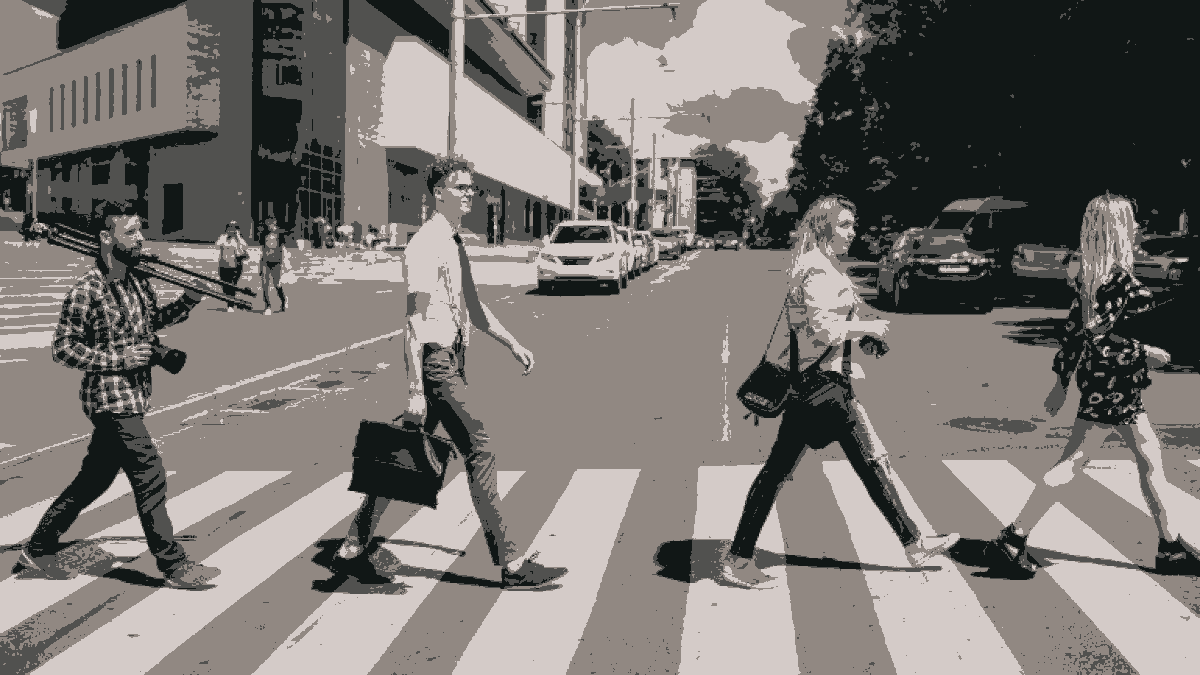

In [11]:
# Reshape the original BGR image into a 2D array of pixels
pixel_values = img.reshape((-1, 3))
# Convert to float32 for cv2.kmeans
pixel_values = np.float32(pixel_values)

# Define criteria: (type, max_iter, epsilon)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)

# Number of clusters (K)
k = 4

# Apply K-means clustering
# compactness: sum of squared distance from each point to their corresponding centers
# labels: label array where each element is the cluster index
# centers: array of centers of clusters
compactness, labels, centers = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

# Convert centers back to uint8
centers = np.uint8(centers)

# Map each pixel to its corresponding center color
kmeans_data = centers[labels.flatten()]

# Reshape back to the original image dimensions
kmeans_img = kmeans_data.reshape((img.shape))

# Display the result
print('K-means Clustering Result (K=4):')
cv2_imshow(kmeans_img)

# Region Based segmentaion

Watershed Segmentation Result:


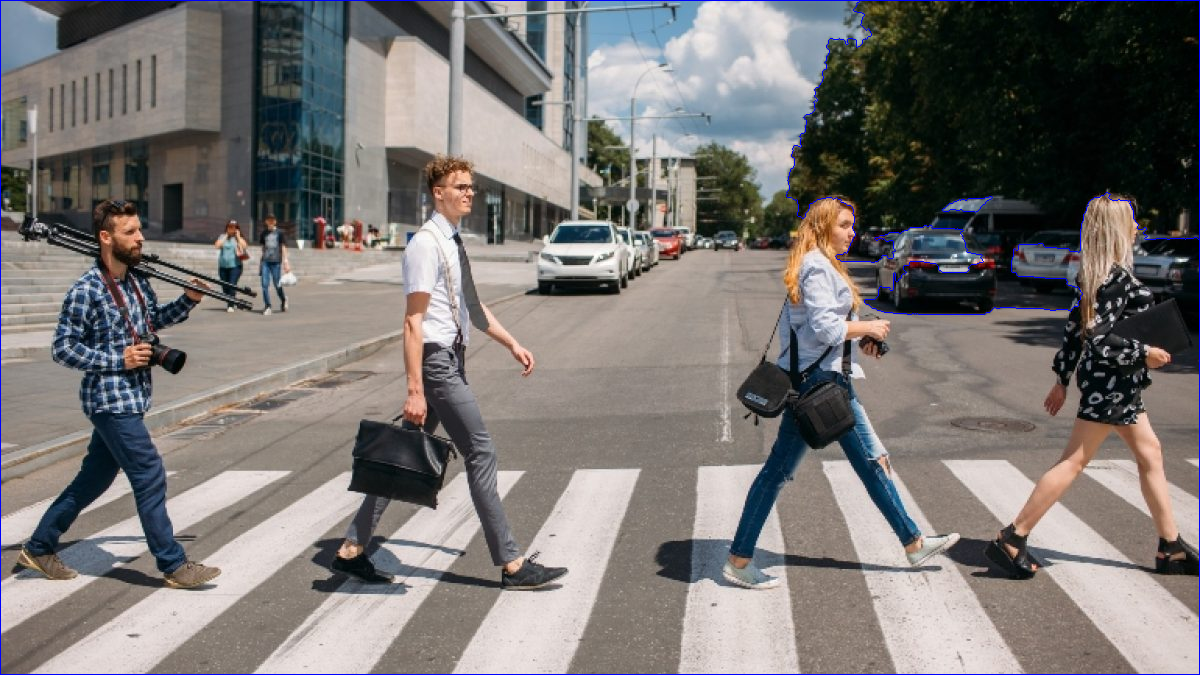

In [12]:
# Step 1: Binary mask and morphological opening
ret, thresh = cv2.threshold(gray_img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# Step 2: Identify sure background and sure foreground
sure_bg = cv2.dilate(opening, kernel, iterations=3)
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
ret, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)
sure_fg = np.uint8(sure_fg)

# Step 3: Find unknown region
unknown = cv2.subtract(sure_bg, sure_fg)

# Step 4: Marker labeling
ret, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

# Step 5: Apply Watershed
watershed_img = img.copy()
markers = cv2.watershed(watershed_img, markers)

# Step 6: Visualize boundaries
watershed_img[markers == -1] = [255, 0, 0]

print('Watershed Segmentation Result:')
cv2_imshow(watershed_img)


#Summary Plot

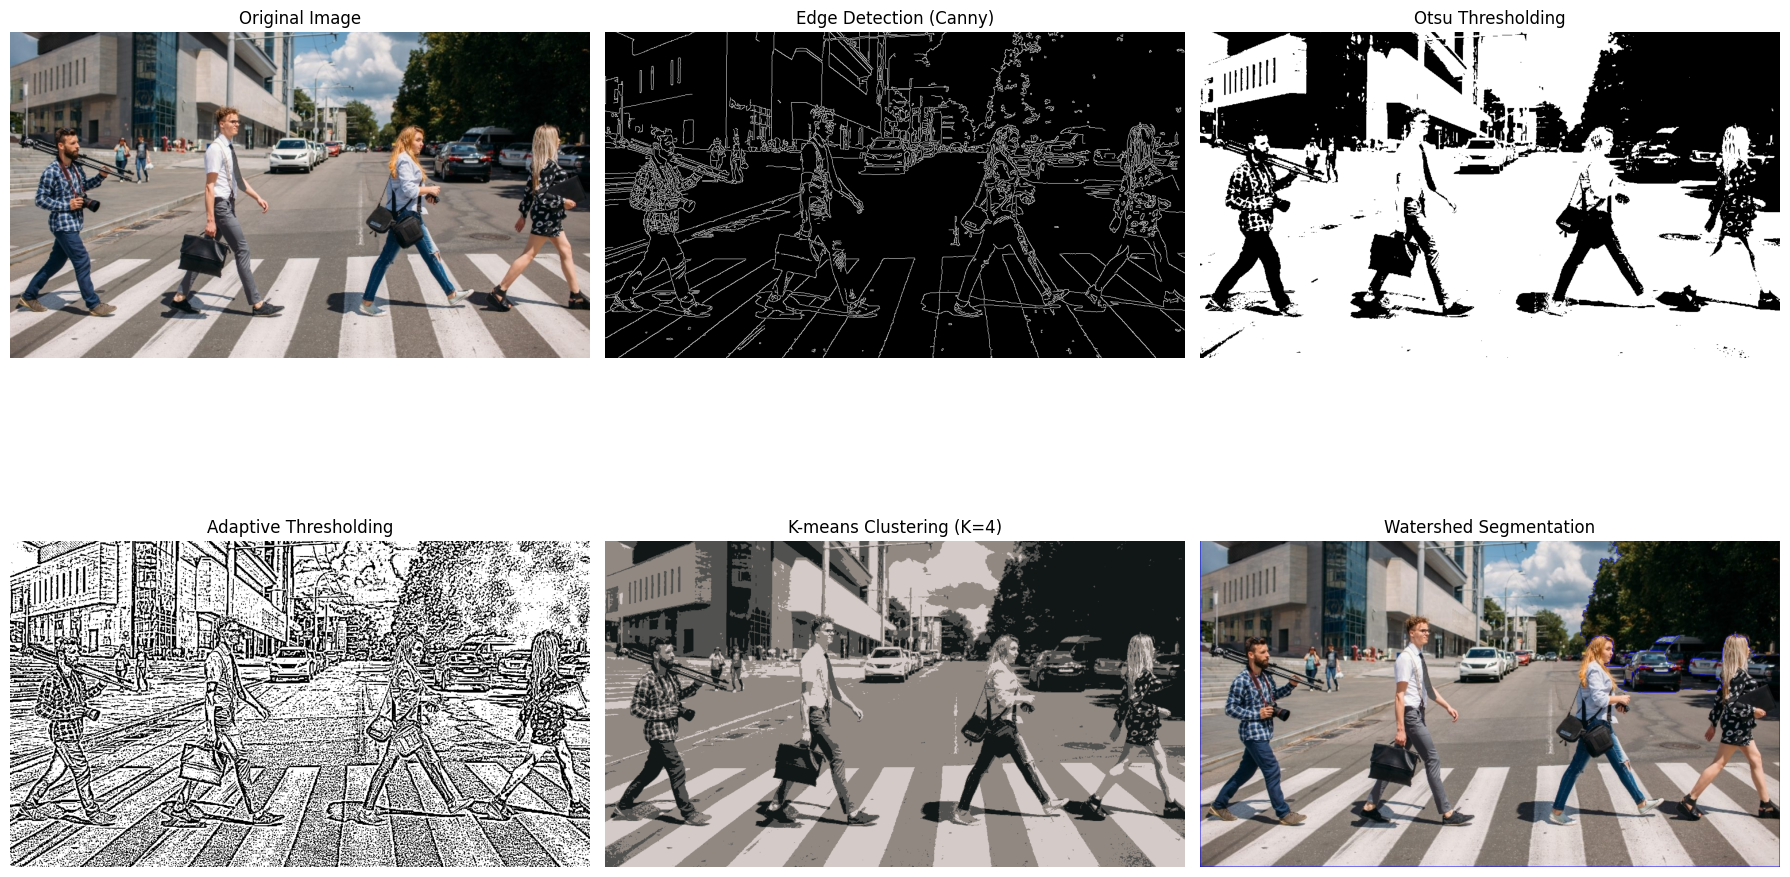

In [13]:
plt.figure(figsize=(18, 12))

# Subplot 1: Original Image
plt.subplot(2, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

# Subplot 2: Edge-based (Canny)
plt.subplot(2, 3, 2)
plt.imshow(edge_img, cmap='gray')
plt.title('Edge Detection (Canny)')
plt.axis('off')

# Subplot 3: Otsu Global Thresholding
plt.subplot(2, 3, 3)
plt.imshow(otsu_thresh, cmap='gray')
plt.title('Otsu Thresholding')
plt.axis('off')

# Subplot 4: Adaptive Gaussian Thresholding
plt.subplot(2, 3, 4)
plt.imshow(adaptive_thresh, cmap='gray')
plt.title('Adaptive Thresholding')
plt.axis('off')

# Subplot 5: K-means Clustering
plt.subplot(2, 3, 5)
plt.imshow(cv2.cvtColor(kmeans_img, cv2.COLOR_BGR2RGB))
plt.title('K-means Clustering (K=4)')
plt.axis('off')

# Subplot 6: Watershed Segmentation
plt.subplot(2, 3, 6)
plt.imshow(cv2.cvtColor(watershed_img, cv2.COLOR_BGR2RGB))
plt.title('Watershed Segmentation')
plt.axis('off')

plt.tight_layout()
plt.show()

#### Hence we have seen the various different techniuqes for segmentation